In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(100))

541


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [12]:
add([1,2])

3

In [22]:
from sage.all import *


def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

j_list=[1,2,3]
test1=h_sequence_from_j(j_list)
print(test1)
test2=j_sequence_from_h(test1)
print(test2)
print("============================================")
j_list=[2,3,5,7,11]
test1=h_sequence_from_j(j_list)
print(test1)
test2=j_sequence_from_h(test1)
print(test2)

[1, 1, 3/2, 13/6]
[1, 2, 3]
[1, 2, 7/2, 6, 79/8, 321/20]
[2, 3, 5, 7, 11]


In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


deformed_h_list[0]: 1
n: 1 elapsed: 0.040733118851979576
n: 2 elapsed: 0.04161438544591268
n: 3 elapsed: 0.04163333574930827
n: 4 elapsed: 0.04172516663869222
n: 5 elapsed: 0.04212543567021688
n: 6 elapsed: 0.04214593569437663
n: 7 elapsed: 0.04217375119527181
n: 8 elapsed: 0.042206021149953206
n: 9 elapsed: 0.04223914941151937
n: 10 elapsed: 0.04228228727976481
n: 11 elapsed: 0.04233702023824056
n: 12 elapsed: 0.042397884527842204
n: 13 elapsed: 0.042483198642730716
n: 14 elapsed: 0.0425649364789327
n: 15 elapsed: 0.042682369550069175
n: 16 elapsed: 0.04279838800430298
n: 17 elapsed: 0.04292280276616414
n: 18 elapsed: 0.043075986703236896
n: 19 elapsed: 0.043230887254079184
n: 20 elapsed: 0.04338796933492025
n: 21 elapsed: 0.04354840119679769
n: 22 elapsed: 0.043745835622151695
n: 23 elapsed: 0.043953967094421384
n: 24 elapsed: 0.04417494932810465
n: 25 elapsed: 0.04444270133972168
n: 26 elapsed: 0.044751115640004474
n: 27 elapsed: 0.045072670777638754
n: 28 elapsed: 0.045428701241811

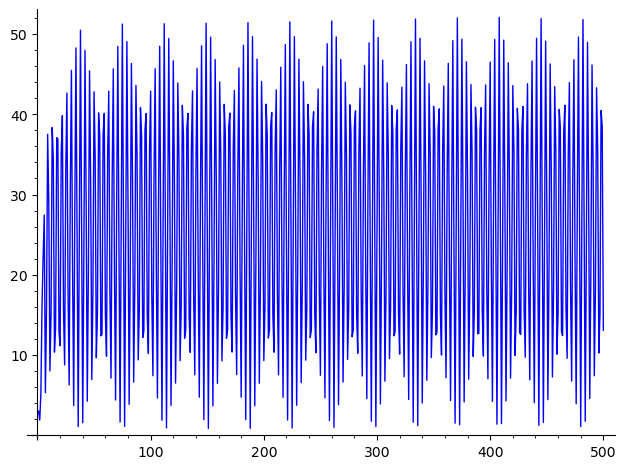

anomalies: 0 249
LOGPLOT


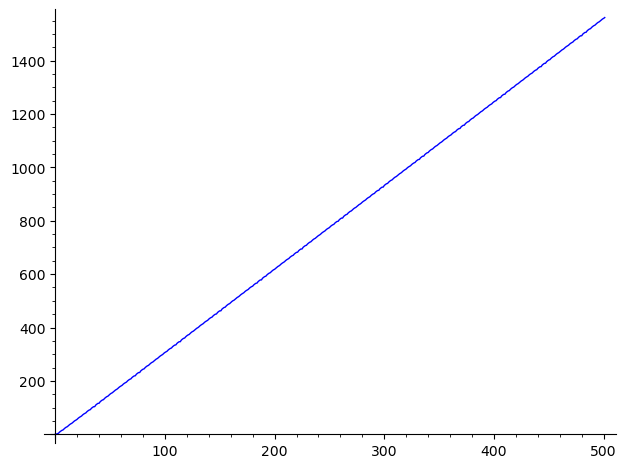

In [1]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(4000) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=3 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

countzeros=0
countnegatives=0
for x in deformed_h_list:
    if x==0:
        countzeros+=1
    if x<0:countnegatives+=1
print("anomalies:",countzeros,countnegatives)   


logplot=[]
for x in deformed_h_list:
    if x==0:
        logplot.append(x)
    if x>0:
        logplot.append(RR(log(x)))
    if x<0:
        logplot.append(RR(log(-x)))

        
p = list_plot(logplot, plotjoined=True, axes_labels=['', ''])
print("LOGPLOT")
p.show()

chi_list_a=chi_list[:300]
chi_list_b=chi_list[301:400]
chi_list_c=chi_list[401:450]
chi_list_d=chi_list[450:480]
chi_list_e=chi_list[481:500]

with open('/Users/barrybrent/data2/run17may26no5.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run17may26no6.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run17may26no7.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run17may26no8.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run17may26no8a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)
with open('/Users/barrybrent/data2/run17may26no8b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)
with open('/Users/barrybrent/data2/run17may26no8c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)
with open('/Users/barrybrent/data2/run17may26no8d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)
with open('/Users/barrybrent/data2/run17may26no8e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)